# AIPI 590 - XAI | Assignment #1
### Description
### Han Wang

#### Include the button below. Change the link to the location in your github repository:
#### Example: https://colab.research.google.com/github/duke-aipi-Han/aipi590-XAI/blob/main/assumption-junction/telco-churn-analysis.ipynb


[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/duke-aipi-Han/aipi590-XAI/blob/main/assumption-junction/telco-churn-analysis.ipynb)

In [29]:
import kagglehub as kh
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from pygam import LogisticGAM, f, s

from statsmodels.stats.outliers_influence import variance_inflation_factor


In [4]:
# download dataset using kagglehub
# https://www.kaggle.com/datasets/blastchar/telco-customer-churn

path = kh.dataset_download("blastchar/telco-customer-churn")
file = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
full_path = os.path.join(path, file)

df = pd.read_csv(full_path)
print("dataframe loaded from:", full_path)
print(f"Dataframe shape: {df.shape}")

dataframe loaded from: /Users/hanwang/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1/WA_Fn-UseC_-Telco-Customer-Churn.csv
Dataframe shape: (7043, 21)


In [5]:
display(df.head(5))

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Task 1:
Exploratory Data Analysis to check Assumptions: Perform an exploratory analysis of the dataset to understand the relationships between different features and the target variable (churn). Use appropriate visualizations and statistical methods to determine whether assumptions about linear, logistic, and GAM models are met. 


### 1.1: Basic EDA of data

In [6]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


None

In [7]:
# why is TotalCharges object type? it should be numeric. let's check the unique values
display(df['TotalCharges'].unique())

# is there a empty string in TotalCharges? let's check
display(df[df['TotalCharges'] == ' '])


# force it to numeric, coerce errors to 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)


array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [8]:
print(df.nunique())

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64


In [9]:
display(df.describe(include='all'))

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043.000000,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,NaN,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,NaN,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,2279.734304,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,2266.794470,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,0.000000,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,398.550000,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1394.550000,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3786.600000,NaN


In [10]:
y_raw = df['Churn']

# drop some columns that are not useful for modeling or not fair
drop_cols = ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Churn']
X_raw = df.drop(drop_cols, axis=1)

In [11]:
# separate continues from categorical variables
continues_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_continuous = X_raw[continues_cols]
X_categorical = X_raw.drop(continues_cols, axis=1)

<Axes: xlabel='Churn', ylabel='count'>

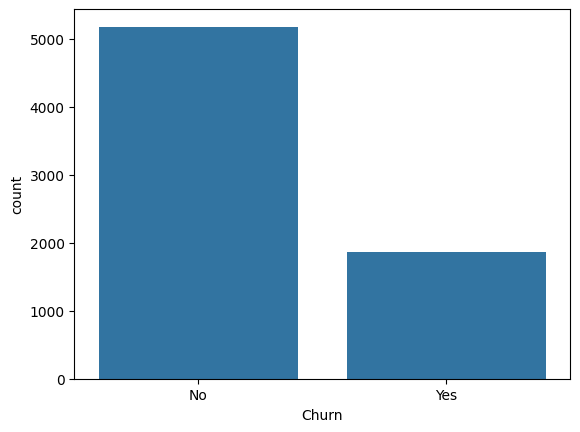

In [12]:
# distribution of response variable is unbalanced, with more "No" than "Yes"
sns.countplot(x='Churn', data=df)

### 1.2: Linear assumptions

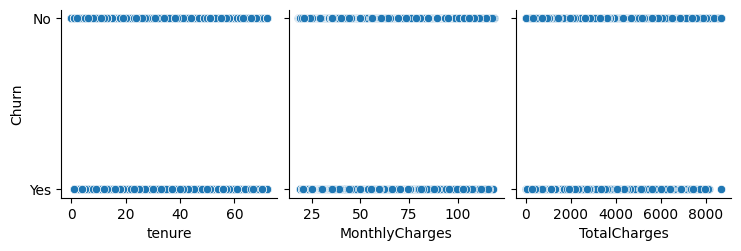

In [13]:
# scatter of each column vs response
sns.pairplot(df, x_vars=X_continuous.columns, y_vars=['Churn'], kind='scatter')

Because the target variable is categorical, difficult to visually see any linearity; Check residuals later

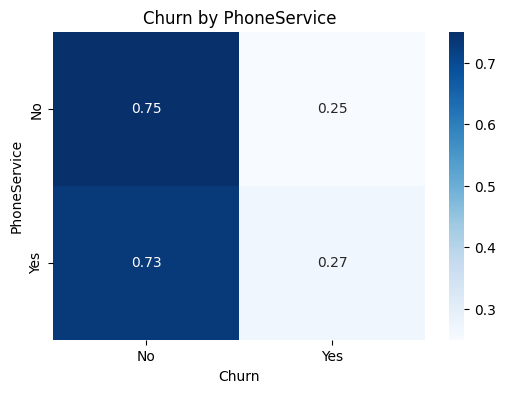

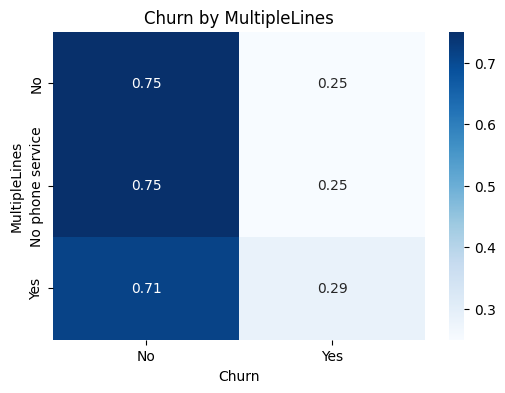

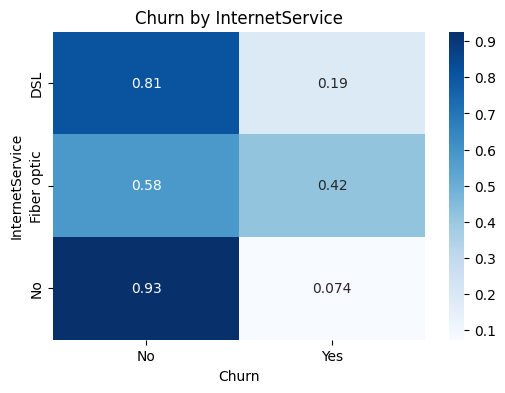

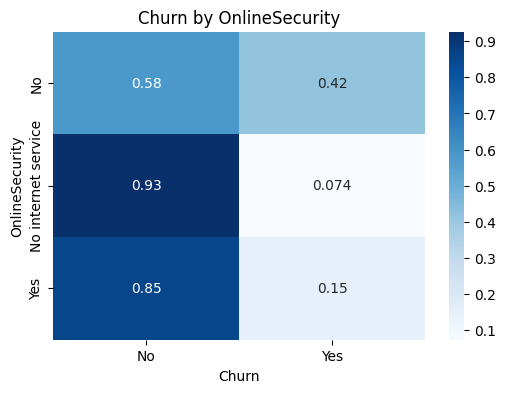

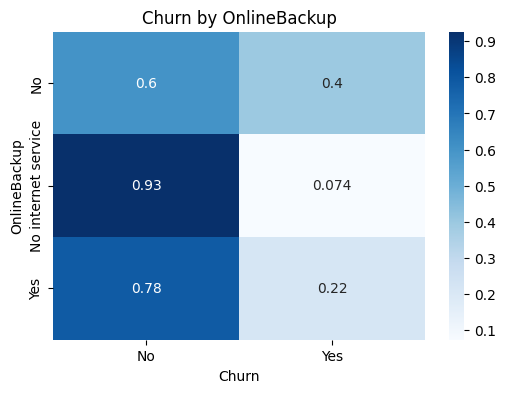

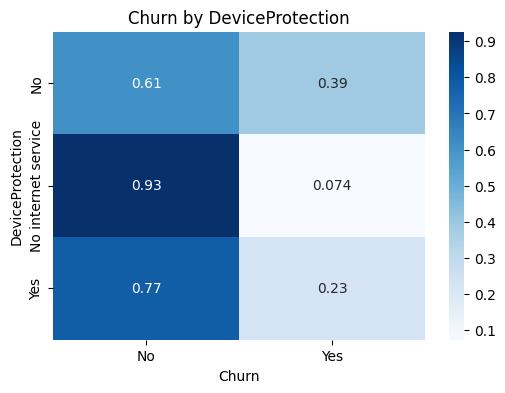

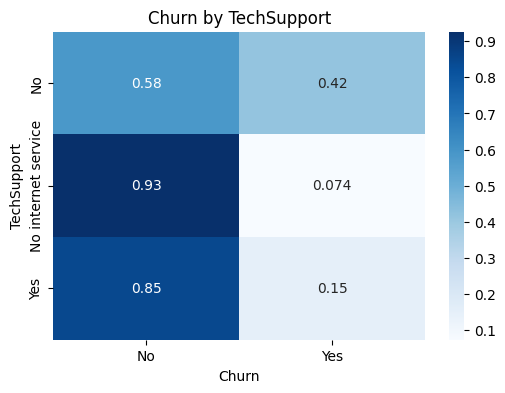

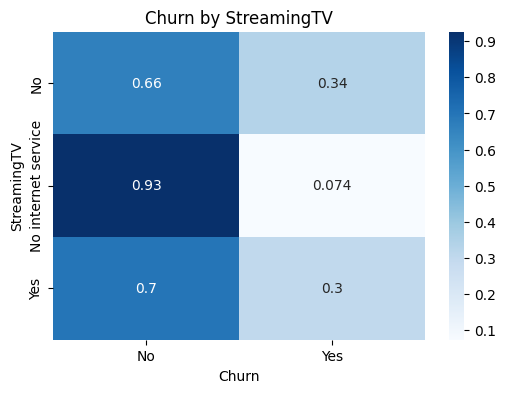

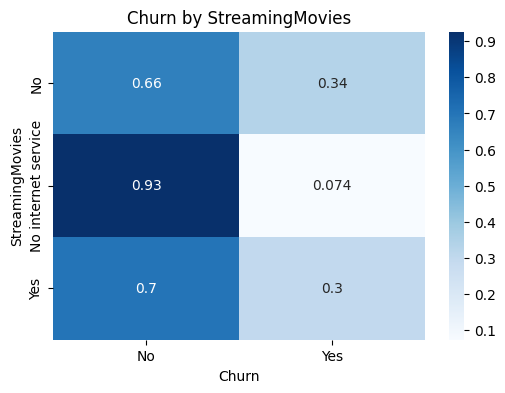

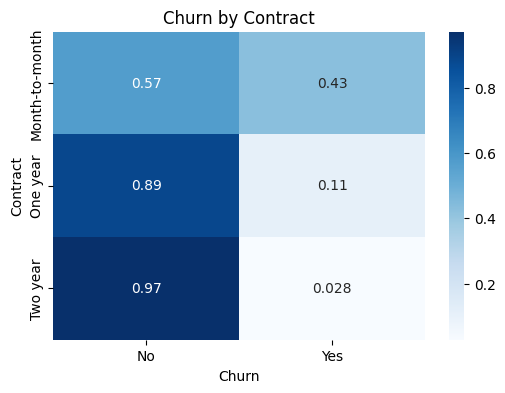

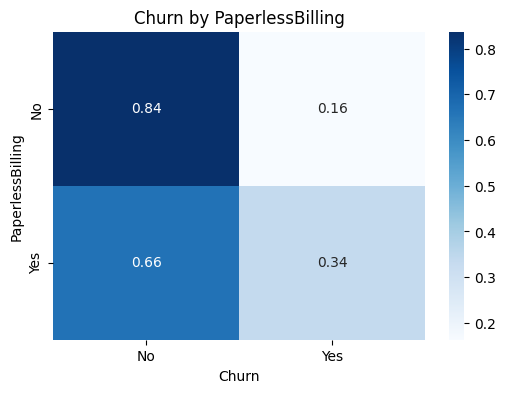

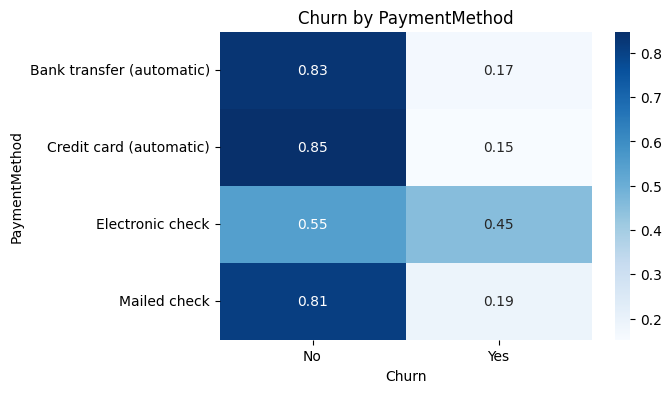

In [14]:
# check categorical predictors; does not require linearity checks.

# churn by categorical variables
categorical_cols = X_categorical.columns

# display heatmaps of each categorical variable vs response variable
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.heatmap(pd.crosstab(df[col], df['Churn'], normalize='index'), annot=True, cmap='Blues')
    plt.title(f'Churn by {col}')
    plt.show()



In [15]:
# independence of observations
# in this dataset, each row is a customer, and each customer is independent of each other. So this assumption is satisfied. Also depends on data collection method.

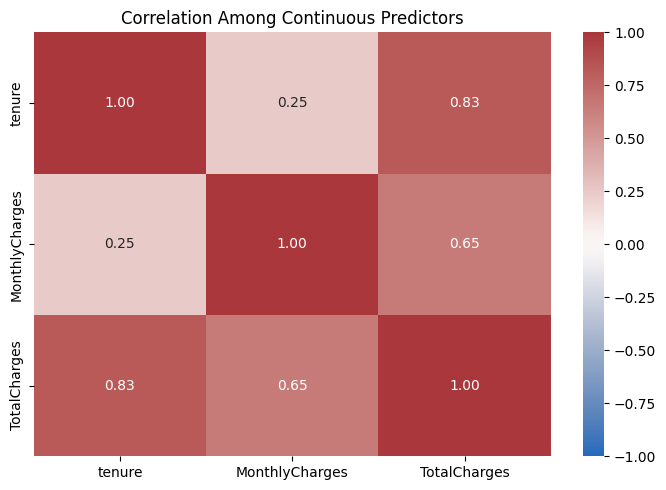

In [16]:
# multicollinearity check
# Check correlations among the continuous predictors.
correlation_matrix = X_continuous.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='vlag',
    center=0,
    vmin=-1,
    vmax=1,
    fmt='.2f'
)
plt.title('Correlation Among Continuous Predictors')
plt.tight_layout()
plt.show()

# Strong correlations, especially between tenure and TotalCharges, indicate
# possible multicollinearity and can make individual model effects unstable.

no surprise that longer tenure means more total charges, so those are correlated. Perhaps drop total charges?

### 1.3: GAM assumptions

Unlike linear regression, GAM uses splines so it can handle non-linearity. It still needs independent observations which is there.
There's some target class imbalance.

## Task 2: 
Linear Regression: Treat the churn variable as a continuous variable (e.g., 0 for staying, 1 for churning) and build a linear regression model to predict churn. Interpret the coefficients and assess the model's performance.


In [17]:
# prep data for regression:
# convert y to continuous variable for regression analysis
y = y_raw.map({'No': 0, 'Yes': 1})

# one-hot encode categorical variables
X = pd.get_dummies(X_raw, drop_first=True)

In [18]:
y.describe()


count    7043.000000
mean        0.265370
std         0.441561
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: Churn, dtype: float64

In [19]:

# perform regression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [20]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{model_name}:")
    print(f"MSE: {mse:.2f}")
    print(f"R2 Score: {r2:.2f}")

    for feature, coef in zip(X.columns, model.coef_):
      print(f"{feature}: {coef:.4f}")

    return model, y_pred

In [21]:
lr_model, lr_pred = evaluate_model(LinearRegression(), X_train_scaled, X_test_scaled, y_train, y_test, "Linear Regression")


Linear Regression:
MSE: 0.13
R2 Score: 0.31
tenure: -0.0456
MonthlyCharges: -0.1318
TotalCharges: -0.0939
PhoneService_Yes: 0.0073
MultipleLines_No phone service: -0.0073
MultipleLines_Yes: 0.0358
InternetService_Fiber optic: 0.1415
InternetService_No: -0.0150
OnlineSecurity_No internet service: -0.0150
OnlineSecurity_Yes: -0.0169
OnlineBackup_No internet service: -0.0150
OnlineBackup_Yes: -0.0006
DeviceProtection_No internet service: -0.0150
DeviceProtection_Yes: 0.0106
TechSupport_No internet service: -0.0150
TechSupport_Yes: -0.0136
StreamingTV_No internet service: -0.0150
StreamingTV_Yes: 0.0422
StreamingMovies_No internet service: -0.0150
StreamingMovies_Yes: 0.0523
Contract_One year: -0.0459
Contract_Two year: -0.0378
PaperlessBilling_Yes: 0.0232
PaymentMethod_Credit card (automatic): -0.0020
PaymentMethod_Electronic check: 0.0342
PaymentMethod_Mailed check: -0.0024


/Users/hanwang/projects/aipi590-XAI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/hanwang/projects/aipi590-XAI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/hanwang/projects/aipi590-XAI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


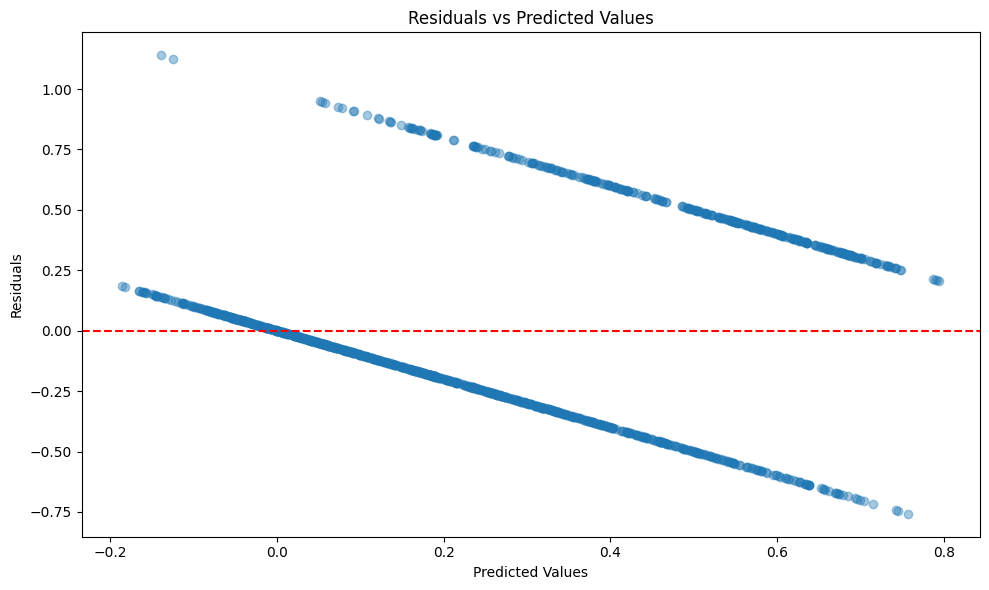

In [22]:
# check for homoscedasticity by plotting residuals vs predicted values
residuals = y_test - lr_pred

plt.figure(figsize=(10, 6))
plt.scatter(lr_pred, residuals, alpha=0.4)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.tight_layout()
plt.show()

# A roughly constant vertical spread supports homoscedasticity.
# A funnel shape or systematic pattern suggests heteroscedasticity.

# the plot below has a funnel shape, which suggests heteroscedasticity. This violates the assumption of homoscedasticity, which states that the variance of the residuals should be constant across all levels of the independent variables. In this case, the variance of the residuals increases as the predicted values increase, indicating that the model's errors are not evenly distributed. This can lead to inefficient estimates and affect the validity of hypothesis tests.

/Users/hanwang/projects/aipi590-XAI/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/hanwang/projects/aipi590-XAI/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/hanwang/projects/aipi590-XAI/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


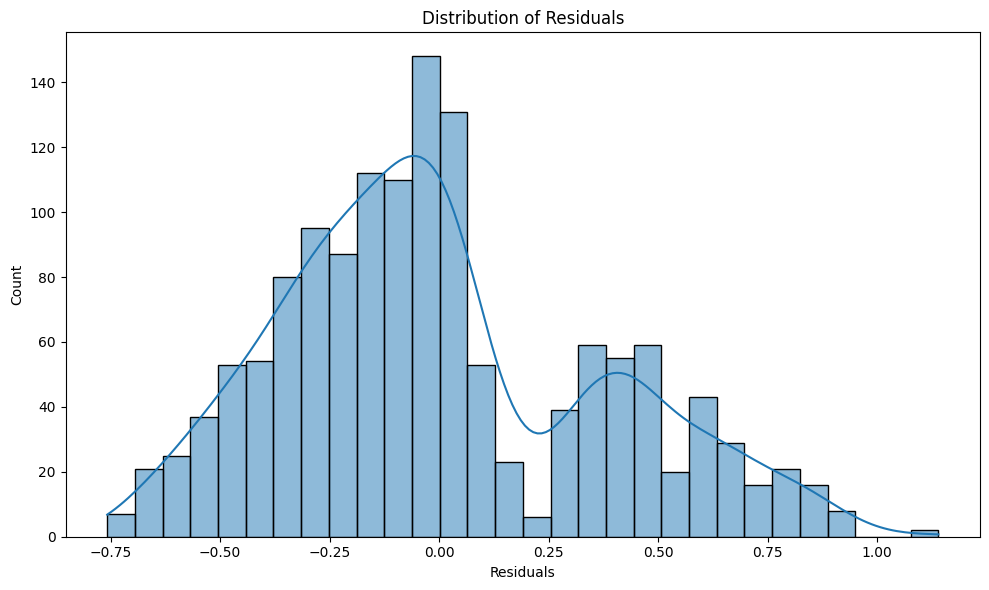

In [23]:
# check for normality of residuals by plotting histogram
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel('Residuals')
plt.ylabel('Count')
plt.title('Distribution of Residuals')
plt.tight_layout()
plt.show()

# For a binary target, residuals are not expected to be perfectly normal.
# This histogram is descriptive because linear regression is being used as a baseline.

# historgrams are bimodal with 2 normal looking peaks (which is expected for binary target variable). This indicates that the residuals are not normally distributed, which violates the assumption of normality. Non-normal residuals can affect the validity of hypothesis tests and confidence intervals, leading to unreliable inferences about the model's coefficients.

## Task 3:
Logistic Regression: Treat churn as a binary variable and build a logistic regression model to predict the probability of churn. Interpret the coefficients.


Logistic Regression Results
Accuracy: 0.818
ROC-AUC: 0.862

Classification Report:
              precision    recall  f1-score   support

    No churn       0.86      0.90      0.88      1036
       Churn       0.67      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.81      1409



/Users/hanwang/projects/aipi590-XAI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/hanwang/projects/aipi590-XAI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/hanwang/projects/aipi590-XAI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/hanwang/projects/aipi590-XAI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/hanwang/projects/aipi590-XAI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encou

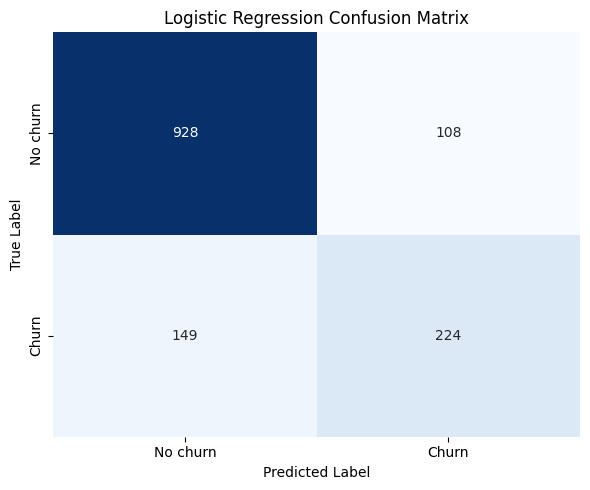

,Feature,Coefficient,Odds Ratio,Importance,Interpretation
0,tenure,-1.357076,0.257412,1.357076,74.3% lower odds of churn
2,TotalCharges,0.671250,1.956682,0.671250,95.7% higher odds of churn
6,InternetService_Fiber optic,0.632016,1.881399,0.632016,88.1% higher odds of churn
21,Contract_Two year,-0.629701,0.532751,0.629701,46.7% lower odds of churn
1,MonthlyCharges,-0.622337,0.536689,0.622337,46.3% lower odds of churn
20,Contract_One year,-0.276779,0.758222,0.276779,24.2% lower odds of churn
19,StreamingMovies_Yes,0.229092,1.257458,0.229092,25.7% higher odds of churn
17,StreamingTV_Yes,0.175883,1.192299,0.175883,19.2% higher odds of churn
5,MultipleLines_Yes,0.171358,1.186916,0.171358,18.7% higher odds of churn
22,PaperlessBilling_Yes,0.169065,1.184197,0.169065,18.4% higher odds of churn


In [30]:
# Fit logistic regression to predict the probability of customer churn.
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_scaled, y_train)

logistic_pred = logistic_model.predict(X_test_scaled)
logistic_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print('Logistic Regression Results')
print(f'Accuracy: {accuracy_score(y_test, logistic_pred):.3f}')
print(f'ROC-AUC: {roc_auc_score(y_test, logistic_prob):.3f}')
print('\nClassification Report:')
print(classification_report(y_test, logistic_pred, target_names=['No churn', 'Churn']))

confusion = confusion_matrix(y_test, logistic_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['No churn', 'Churn'],
    yticklabels=['No churn', 'Churn']
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.show()

# Coefficients are based on standardized predictors.
# For numeric variables, odds ratios describe a one-standard-deviation increase.
# For one-hot variables, they compare that category with its omitted reference category.
odds_ratios = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logistic_model.coef_[0],
    'Odds Ratio': np.exp(logistic_model.coef_[0])
})
odds_ratios['Importance'] = odds_ratios['Coefficient'].abs()
odds_ratios['Interpretation'] = np.where(
    odds_ratios['Odds Ratio'] > 1,
    ((odds_ratios['Odds Ratio'] - 1) * 100).round(1).astype(str)
    + '% higher odds of churn',
    ((1 - odds_ratios['Odds Ratio']) * 100).round(1).astype(str)
    + '% lower odds of churn'
)
odds_ratios = odds_ratios.sort_values('Importance', ascending=False)

display(odds_ratios.head(15))

## Task 4:
Generalized Additive Model (GAM): Build a GAM to model the non-linear relationships between customer features and churn. Interpret the GAM model. 


Generalized Additive Model Results
Accuracy: 0.817
ROC-AUC: 0.863

Classification Report:
              precision    recall  f1-score   support

    No churn       0.85      0.91      0.88      1036
       Churn       0.69      0.57      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



/Users/hanwang/projects/aipi590-XAI/.venv/lib/python3.13/site-packages/scipy/linalg/_basic.py:1648: RuntimeWarning: divide by zero encountered in matmul
  B = (u @ vh[:rank]).conj().T
/Users/hanwang/projects/aipi590-XAI/.venv/lib/python3.13/site-packages/scipy/linalg/_basic.py:1648: RuntimeWarning: overflow encountered in matmul
  B = (u @ vh[:rank]).conj().T
/Users/hanwang/projects/aipi590-XAI/.venv/lib/python3.13/site-packages/scipy/linalg/_basic.py:1648: RuntimeWarning: invalid value encountered in matmul
  B = (u @ vh[:rank]).conj().T


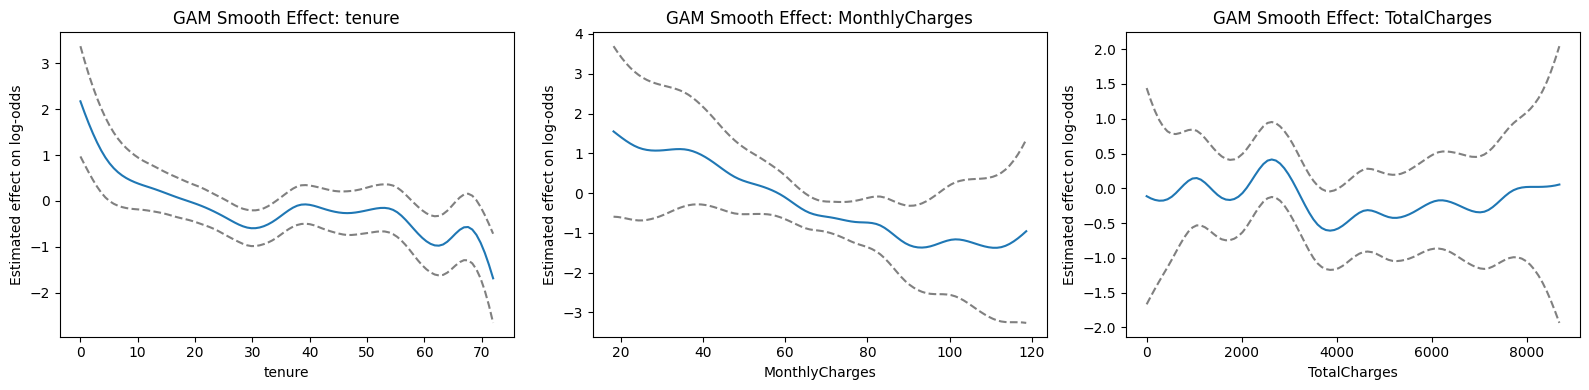

The GAM uses smooth terms for the continuous predictors and factor terms for categorical predictors.
Interpret the smooth-effect plots as changes in log-odds, holding the other predictors constant.


In [31]:

# Build GAM features: smooth terms for continuous variables and factor terms for categories.
X_gam = X_continuous.copy()
for column in X_categorical.columns:
    X_gam[column] = pd.Categorical(X_categorical[column]).codes

# Reuse the same train/test observations as the linear and logistic models.
X_gam_train = X_gam.loc[X_train.index]
X_gam_test = X_gam.loc[X_test.index]

gam_terms = s(0) + s(1) + s(2)
for term_index in range(3, X_gam.shape[1]):
    gam_terms += f(term_index)

gam_model = LogisticGAM(gam_terms).fit(X_gam_train, y_train)
gam_pred = gam_model.predict(X_gam_test)
gam_prob = gam_model.predict_proba(X_gam_test)

print('Generalized Additive Model Results')
print(f'Accuracy: {accuracy_score(y_test, gam_pred):.3f}')
print(f'ROC-AUC: {roc_auc_score(y_test, gam_prob):.3f}')
print('\nClassification Report:')
print(classification_report(y_test, gam_pred, target_names=['No churn', 'Churn']))

# Plot the estimated smooth effects for the continuous predictors.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for term_index, column in enumerate(continues_cols):
    XX = gam_model.generate_X_grid(term=term_index)
    partial_dependence, confidence_intervals = gam_model.partial_dependence(
        term=term_index,
        X=XX,
        width=0.95
    )
    axes[term_index].plot(XX[:, term_index], partial_dependence)
    axes[term_index].plot(
        XX[:, term_index],
        confidence_intervals,
        linestyle='--',
        color='gray'
    )
    axes[term_index].set_xlabel(column)
    axes[term_index].set_ylabel('Estimated effect on log-odds')
    axes[term_index].set_title(f'GAM Smooth Effect: {column}')

plt.tight_layout()
plt.show()

print('The GAM uses smooth terms for the continuous predictors and factor terms for categorical predictors.')
print('Interpret the smooth-effect plots as changes in log-odds, holding the other predictors constant.')

## Task 5:
Model Comparison: Compare the performance and interpretability of the different models you built. Discuss the strengths and weaknesses of each approach and provide recommendations for which model(s) the telecommunications company should use to address their customer churn problem.

In [32]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Use the same test observations and threshold for a simple model comparison.
model_predictions = {
    'Linear Regression': ((lr_pred >= 0.5).astype(int), lr_pred),
    'Logistic Regression': (logistic_pred, logistic_prob),
    'GAM': (gam_pred, gam_prob)
}

comparison = []
for model_name, (predictions, probabilities) in model_predictions.items():
    comparison.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision (Churn)': precision_score(y_test, predictions),
        'Recall (Churn)': recall_score(y_test, predictions),
        'F1 Score (Churn)': f1_score(y_test, predictions),
        'ROC-AUC': roc_auc_score(y_test, probabilities)
    })

comparison = pd.DataFrame(comparison).sort_values('ROC-AUC', ascending=False)
display(comparison.round(3))

print('Interpretation:')
print('- Linear regression is included as a simple baseline, but it is not designed for binary outcomes.')
print('- Logistic regression provides an interpretable linear relationship in log-odds.')
print('- GAM provides interpretable nonlinear smooth effects while retaining probability predictions.')
print('- For churn prediction, ROC-AUC, churn recall, and calibration should be considered together; accuracy alone can hide missed churners.')

,Model,Accuracy,Precision (Churn),Recall (Churn),F1 Score (Churn),ROC-AUC
2,GAM,0.817,0.686,0.568,0.622,0.863
1,Logistic Regression,0.818,0.675,0.601,0.635,0.862
0,Linear Regression,0.820,0.694,0.571,0.626,0.855


Interpretation:
- Linear regression is included as a simple baseline, but it is not designed for binary outcomes.
- Logistic regression provides an interpretable linear relationship in log-odds.
- GAM provides interpretable nonlinear smooth effects while retaining probability predictions.
- For churn prediction, ROC-AUC, churn recall, and calibration should be considered together; accuracy alone can hide missed churners.


In [33]:
# Refit logistic regression and GAM after removing the redundant TotalCharges feature.
X_trimmed_raw = X_raw.drop(columns=['TotalCharges'])
X_trimmed = pd.get_dummies(X_trimmed_raw, drop_first=True)

X_trimmed_train, X_trimmed_test, y_trimmed_train, y_trimmed_test = train_test_split(
    X_trimmed,
    y,
    test_size=0.2,
    random_state=42
)

trimmed_scaler = StandardScaler()
X_trimmed_train_scaled = trimmed_scaler.fit_transform(X_trimmed_train)
X_trimmed_test_scaled = trimmed_scaler.transform(X_trimmed_test)

trimmed_logistic_model = LogisticRegression(max_iter=1000, random_state=42)
trimmed_logistic_model.fit(X_trimmed_train_scaled, y_trimmed_train)
trimmed_logistic_pred = trimmed_logistic_model.predict(X_trimmed_test_scaled)
trimmed_logistic_prob = trimmed_logistic_model.predict_proba(X_trimmed_test_scaled)[:, 1]

# Prepare the same trimmed features for a GAM.
trimmed_continuous_cols = ['tenure', 'MonthlyCharges']
trimmed_categorical_cols = X_trimmed_raw.columns.difference(trimmed_continuous_cols)
X_trimmed_gam = X_trimmed_raw[trimmed_continuous_cols].copy()

for column in trimmed_categorical_cols:
    X_trimmed_gam[column] = pd.Categorical(X_trimmed_raw[column]).codes

X_trimmed_gam_train = X_trimmed_gam.loc[X_trimmed_train.index]
X_trimmed_gam_test = X_trimmed_gam.loc[X_trimmed_test.index]
trimmed_gam_terms = s(0) + s(1)

for term_index in range(2, X_trimmed_gam.shape[1]):
    trimmed_gam_terms += f(term_index)

trimmed_gam_model = LogisticGAM(trimmed_gam_terms).fit(
    X_trimmed_gam_train,
    y_trimmed_train
)
trimmed_gam_pred = trimmed_gam_model.predict(X_trimmed_gam_test)
trimmed_gam_prob = trimmed_gam_model.predict_proba(X_trimmed_gam_test)

trimmed_comparison = pd.DataFrame([
    {
        'Model': 'Trimmed Logistic Regression',
        'Accuracy': accuracy_score(y_trimmed_test, trimmed_logistic_pred),
        'Precision (Churn)': precision_score(y_trimmed_test, trimmed_logistic_pred),
        'Recall (Churn)': recall_score(y_trimmed_test, trimmed_logistic_pred),
        'F1 Score (Churn)': f1_score(y_trimmed_test, trimmed_logistic_pred),
        'ROC-AUC': roc_auc_score(y_trimmed_test, trimmed_logistic_prob)
    },
    {
        'Model': 'Trimmed GAM',
        'Accuracy': accuracy_score(y_trimmed_test, trimmed_gam_pred),
        'Precision (Churn)': precision_score(y_trimmed_test, trimmed_gam_pred),
        'Recall (Churn)': recall_score(y_trimmed_test, trimmed_gam_pred),
        'F1 Score (Churn)': f1_score(y_trimmed_test, trimmed_gam_pred),
        'ROC-AUC': roc_auc_score(y_trimmed_test, trimmed_gam_prob)
    }
]).sort_values('ROC-AUC', ascending=False)

display(trimmed_comparison.round(3))
print('TotalCharges was removed because it is strongly correlated with tenure.')
print('Compare ROC-AUC, churn recall, and calibration when deciding between the trimmed models.')

/Users/hanwang/projects/aipi590-XAI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/hanwang/projects/aipi590-XAI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/hanwang/projects/aipi590-XAI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/hanwang/projects/aipi590-XAI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/hanwang/projects/aipi590-XAI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encou

,Model,Accuracy,Precision (Churn),Recall (Churn),F1 Score (Churn),ROC-AUC
1,Trimmed GAM,0.809,0.669,0.552,0.605,0.863
0,Trimmed Logistic Regression,0.822,0.688,0.598,0.640,0.860


TotalCharges was removed because it is strongly correlated with tenure.
Compare ROC-AUC, churn recall, and calibration when deciding between the trimmed models.
